In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3579178.0650697174


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2859/2859 [00:00<00:00, 107363.31it/s]
Computing layer execution times: 3000it [00:00, 471694.11it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 2859
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.6732 seconds


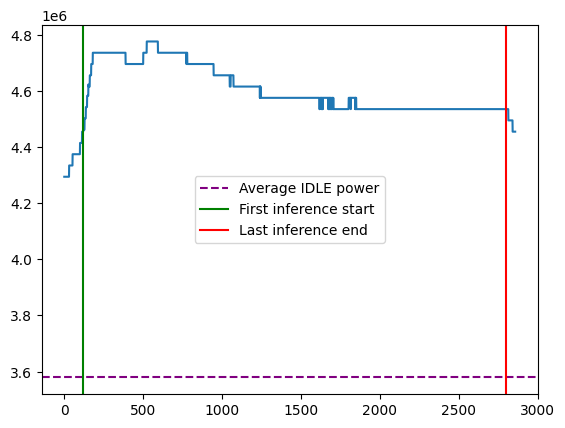

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 713924.09it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.747000e+03,1.747000e+03,3000.000000
mean,1500.500000,4.608916e+06,1.029738e+06,0.816979
std,866.169729,8.262556e+04,8.262556e+04,0.115955
min,1.000000,4.454208e+06,8.750299e+05,0.381344
25%,750.750000,4.534464e+06,9.552859e+05,0.804736
50%,1500.500000,4.574592e+06,9.954139e+05,0.826864
75%,2250.250000,4.694976e+06,1.115798e+06,0.855008
max,3000.000000,4.775232e+06,1.196054e+06,3.931040


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1747
layer_power_excluding_idle_power_micro_watt    1747
layer_run_time                                 3000
dtype: int64

<Axes: >

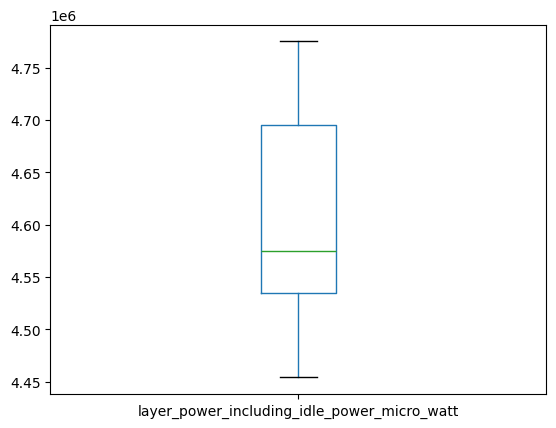

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 6

In [11]:
model_name = 'conv_k1_s1_o6'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3006/3006 [00:00<00:00, 88612.68it/s]
Computing layer execution times: 3000it [00:00, 483660.52it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o6: 3006
Number of TensorRT layers in conv_k1_s1_o6: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.760839 seconds


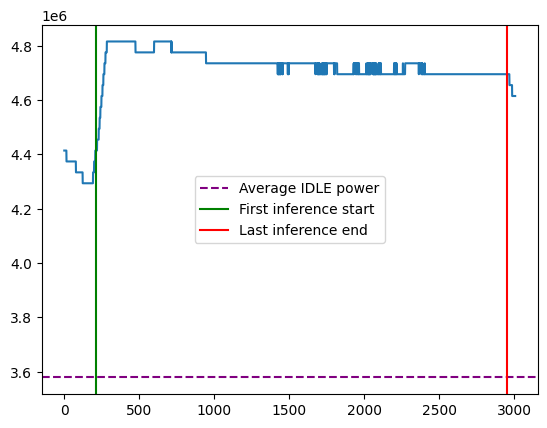

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 968288.73it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.840000e+03,1.840000e+03,3000.000000
mean,1500.500000,4.732443e+06,1.153265e+06,0.841712
std,866.169729,4.858581e+04,4.858581e+04,0.126551
min,1.000000,4.414080e+06,8.349019e+05,0.389792
25%,750.750000,4.694976e+06,1.115798e+06,0.842368
50%,1500.500000,4.735104e+06,1.155926e+06,0.847296
75%,2250.250000,4.775232e+06,1.196054e+06,0.860648
max,3000.000000,4.815360e+06,1.236182e+06,3.521376


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1840
layer_power_excluding_idle_power_micro_watt    1840
layer_run_time                                 3000
dtype: int64

<Axes: >

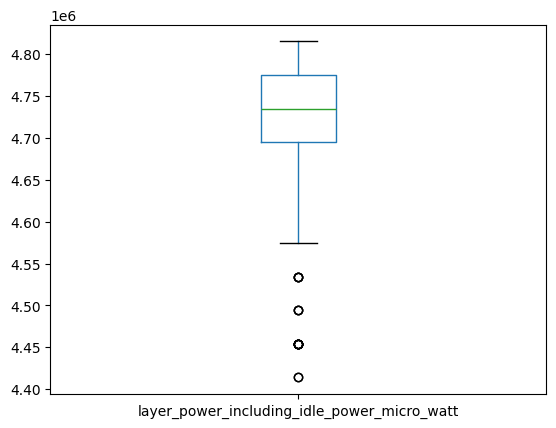

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 12

In [18]:
model_name = 'conv_k1_s1_o12'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3402/3402 [00:00<00:00, 90588.34it/s]
Computing layer execution times: 3000it [00:00, 522394.32it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o12: 3402
Number of TensorRT layers in conv_k1_s1_o12: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.275921 seconds


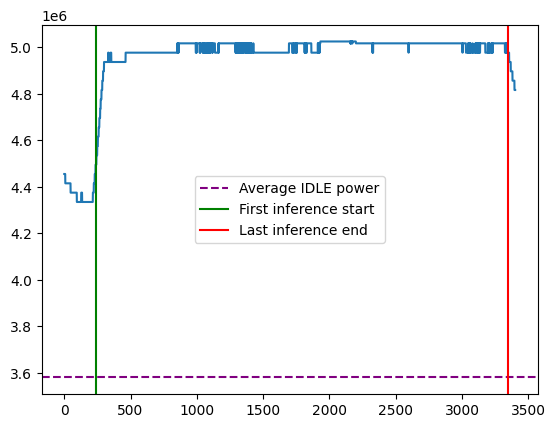

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 420664.35it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.165000e+03,2.165000e+03,3000.000000
mean,1500.500000,4.994418e+06,1.415240e+06,1.003860
std,866.169729,4.616565e+04,4.616565e+04,0.125359
min,1.000000,4.534464e+06,9.552859e+05,0.450848
25%,750.750000,4.975872e+06,1.396694e+06,1.005088
50%,1500.500000,5.016000e+06,1.436822e+06,1.011168
75%,2250.250000,5.016000e+06,1.436822e+06,1.023328
max,3000.000000,5.024000e+06,1.444822e+06,3.754464


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2165
layer_power_excluding_idle_power_micro_watt    2165
layer_run_time                                 3000
dtype: int64

<Axes: >

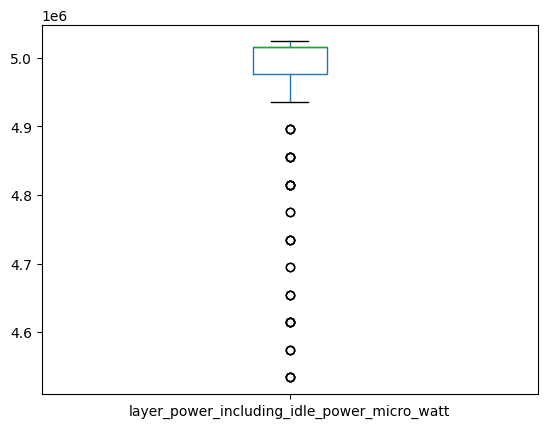

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 24

In [25]:
model_name = 'conv_k1_s1_o24'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3511/3511 [00:00<00:00, 107224.42it/s]
Computing layer execution times: 3000it [00:00, 42225.95it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o24: 3511
Number of TensorRT layers in conv_k1_s1_o24: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.439339 seconds


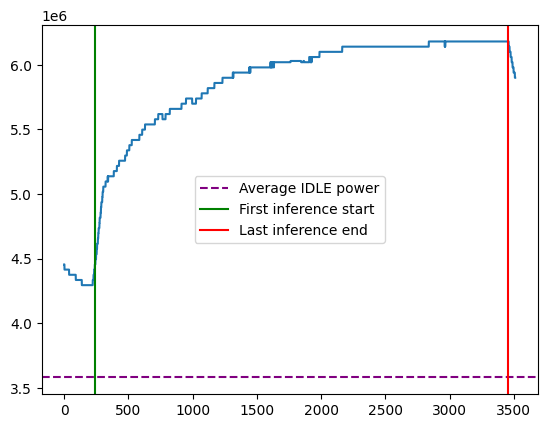

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 687478.12it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.107000e+03,2.107000e+03,3000.000000
mean,1500.500000,5.891314e+06,2.312136e+06,1.101710
std,866.169729,3.207206e+05,3.207206e+05,0.141573
min,1.000000,4.614720e+06,1.035542e+06,0.452960
25%,750.750000,5.698176e+06,2.118998e+06,1.059888
50%,1500.500000,6.019200e+06,2.440022e+06,1.094816
75%,2250.250000,6.139584e+06,2.560406e+06,1.114008
max,3000.000000,6.179712e+06,2.600534e+06,3.807552


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2107
layer_power_excluding_idle_power_micro_watt    2107
layer_run_time                                 3000
dtype: int64

<Axes: >

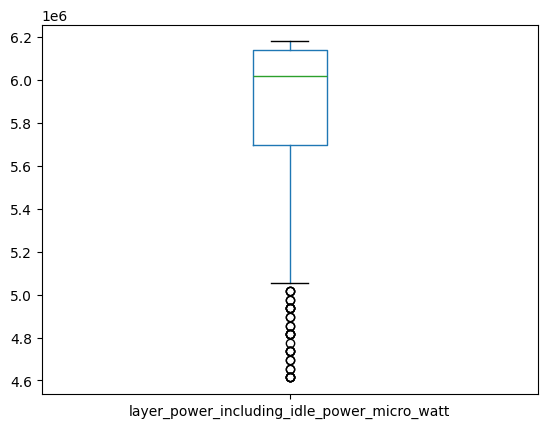

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 48

In [32]:
model_name = 'conv_k1_s1_o48'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4318/4318 [00:00<00:00, 77780.71it/s]
Computing layer execution times: 3000it [00:00, 466846.44it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o48: 4318
Number of TensorRT layers in conv_k1_s1_o48: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 5.523 seconds


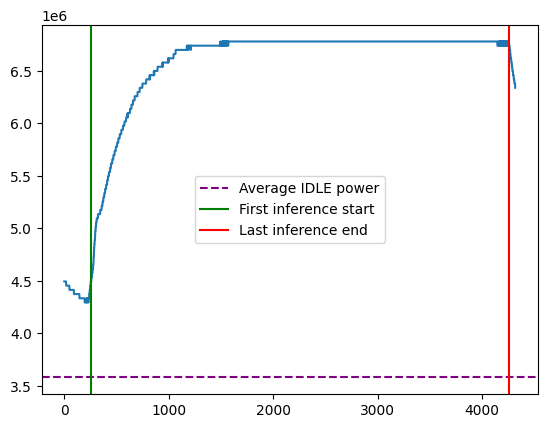

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 828531.77it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.970000e+03,2.970000e+03,3000.000000
mean,1500.500000,6.639495e+06,3.060317e+06,1.419628
std,866.169729,3.489482e+05,3.489482e+05,0.089745
min,1.000000,4.494336e+06,9.151579e+05,0.652544
25%,750.750000,6.741504e+06,3.162326e+06,1.408448
50%,1500.500000,6.781632e+06,3.202454e+06,1.413280
75%,2250.250000,6.781632e+06,3.202454e+06,1.425800
max,3000.000000,6.781632e+06,3.202454e+06,3.989472


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2970
layer_power_excluding_idle_power_micro_watt    2970
layer_run_time                                 3000
dtype: int64

<Axes: >

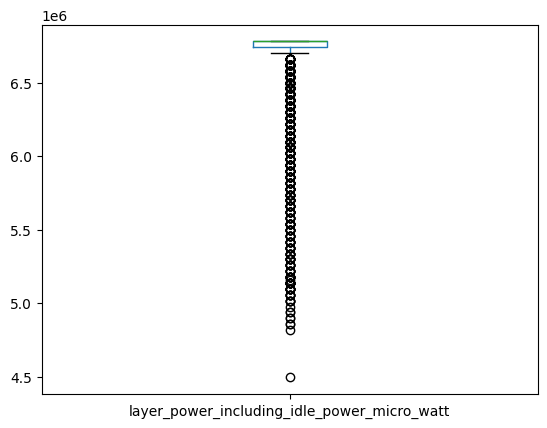

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Output shape Plot

Text(0.5, 0, 'Output shape')

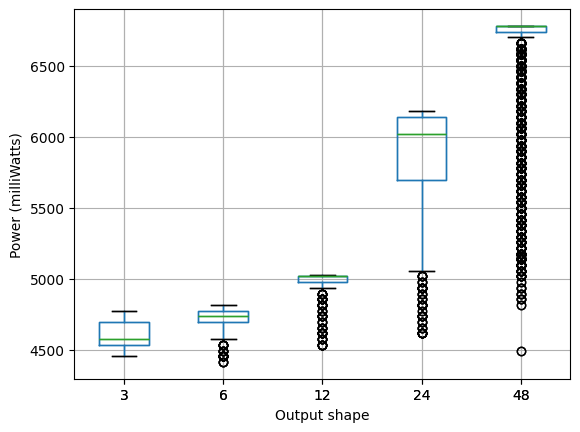

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)

# set column names (will be displayed as plot labels)
df.columns = ['3', '6', '12', '24', '48']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Output shape')